# Data Exploration


*Dataset*: https://huggingface.co/datasets/postbot/aeslc_kw

*Citation*:  
@InProceedings{zhang2019slg,  
  author =      "Rui Zhang and Joel Tetreault",  
  title =       "This Email Could Save Your Life: Introducing the Task of Email  
  Subject Line Generation",  
  booktitle =   "Proceedings of The 57th Annual Meeting of the Association for Computational Linguistics",  
  year =        "2019",  
  address =     "Florence, Italy"
}

This Hugging Face dataset contains the email body, clean email, and subject line fields. These fields will be used for two tasks: email continuation and email subject generation.

### Setup

In [30]:
# import libraries
from datasets import load_dataset
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


### Load Dataset

In [ ]:
ds = load_dataset("postbot/aeslc_kw")

README.md:   0%|          | 0.00/1.46k [00:00<?, ?B/s]

train.csv: reconstructing file:   0%|          |  0.00B / 24.2MB            

train.csv: downloading bytes:           |  0.00B            

validation.csv:   0%|          | 0.00/3.42M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/2.98M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/14436 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1960 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1906 [00:00<?, ? examples/s]

In [2]:
ds

DatasetDict({
    train: Dataset({
        features: ['email_body', 'subject_line', 'clean_email', 'clean_email_keywords'],
        num_rows: 14436
    })
    validation: Dataset({
        features: ['email_body', 'subject_line', 'clean_email', 'clean_email_keywords'],
        num_rows: 1960
    })
    test: Dataset({
        features: ['email_body', 'subject_line', 'clean_email', 'clean_email_keywords'],
        num_rows: 1906
    })
})

In [11]:
# convert the dataset to pandas DataFrames
train_df = pd.DataFrame(ds['train'])
validation_df = pd.DataFrame(ds['validation'])
test_df = pd.DataFrame(ds['test'])

### Data Exploration
1. general dataset info
2. dataset examples
3. check duplicates
4. check word counts

#### General dataset info

In [12]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14436 entries, 0 to 14435
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   email_body            14436 non-null  str  
 1   subject_line          14436 non-null  str  
 2   clean_email           14436 non-null  str  
 3   clean_email_keywords  14436 non-null  str  
dtypes: str(4)
memory usage: 23.4 MB


In [13]:
validation_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1960 entries, 0 to 1959
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   email_body            1960 non-null   str  
 1   subject_line          1960 non-null   str  
 2   clean_email           1960 non-null   str  
 3   clean_email_keywords  1960 non-null   str  
dtypes: str(4)
memory usage: 3.3 MB


In [14]:
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1906 entries, 0 to 1905
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   email_body            1906 non-null   str  
 1   subject_line          1906 non-null   str  
 2   clean_email           1906 non-null   str  
 3   clean_email_keywords  1906 non-null   str  
dtypes: str(4)
memory usage: 2.9 MB


In [16]:
train_df.head(5)

,email_body,subject_line,clean_email,clean_email_keywords
0,"Greg/Phillip, Attached is the Grande Communic...",Service Agreement,"Greg/Phillip, Attached is the Grande Communica...",bishopscontract doc hunter williams agreement ...
1,Phillip & Keith Attached is the first draw re...,Bishops Corner,Phillip & Keith Attached is the first draw req...,contracts signed elect vice president handle p...
2,Your Internet Banking accounts are now setup a...,Internet Banking,Your Internet Banking accounts are now setup a...,primary types descriptions change state zip nu...
3,To our IBS Customers that are still hanging in...,Internet Banking,To our IBS Customers that are still hanging in...,accounts ibs access entering information click...
4,Phillip Good Morning!\nI hope you had a wonder...,SMEs for expert stories,Phillip Good Morning!\nI hope you had a wonder...,thanksgiving phillip good morning list contact...


#### Dataset examples

In [ ]:
# print the first 3 examples in the training dataset
for i in range(3):
    print(f'Example {i+1}: \n')
    print('Email body:')
    print(train_df['email_body'][i])
    print('Clean email body:')
    print(train_df['clean_email'][i])
    print('Subject:')
    print(train_df['subject_line'][i])
    print('------')

Example 1: 

Email body:
Greg/Phillip,  Attached is the Grande Communications Service Agreement.
The business points can be found in Exhibit C.  I Can get the Non-Disturbance agreement after it has been executed by you and Grande.
I will fill in the Legal description of the property one I have received it.
Please execute and send to:  Grande Communications, 401 Carlson Circle, San Marcos Texas, 78666 Attention Hunter Williams.
<<Bishopscontract.doc>>

Clean email body:
Greg/Phillip, Attached is the Grande Communications Service Agreement.
The business points can be found in Exhibit C. I Can get the Non-Disturbance agreement after it has been executed by you and Grande.
I will fill in the Legal description of the property one I have received it.
Please execute and send to: Grande Communications, <NUMBER> Carlson Circle, San Marcos <STATE>, <NUMBER> Attention Hunter Williams.
<<Bishopscontract.doc>>
Subject:
Service Agreement
------
Example 2: 

Email body:
Phillip & Keith  Attached is t

#### Check duplicates

In [23]:
print(f'Training data duplicates: {train_df.duplicated().sum()}')
print(f'Validation data duplicates: {validation_df.duplicated().sum()}')
print(f'Test data duplicates: {test_df.duplicated().sum()}')    

Training data duplicates: 0
Validation data duplicates: 0
Test data duplicates: 0


#### Check word count

In [ ]:
# add word count columns to the traininig dataset
train_df['clean_email_word_count'] = train_df['clean_email'].str.split().str.len()
train_df['subject_word_count'] = train_df['subject_line'].str.split().str.len()

In [28]:
train_df.head(5)

,email_body,subject_line,clean_email,clean_email_keywords,clean_email_word_count,subject_word_count
0,"Greg/Phillip, Attached is the Grande Communic...",Service Agreement,"Greg/Phillip, Attached is the Grande Communica...",bishopscontract doc hunter williams agreement ...,65,2
1,Phillip & Keith Attached is the first draw re...,Bishops Corner,Phillip & Keith Attached is the first draw req...,contracts signed elect vice president handle p...,145,2
2,Your Internet Banking accounts are now setup a...,Internet Banking,Your Internet Banking accounts are now setup a...,primary types descriptions change state zip nu...,250,2
3,To our IBS Customers that are still hanging in...,Internet Banking,To our IBS Customers that are still hanging in...,accounts ibs access entering information click...,458,2
4,Phillip Good Morning!\nI hope you had a wonder...,SMEs for expert stories,Phillip Good Morning!\nI hope you had a wonder...,thanksgiving phillip good morning list contact...,68,4


In [29]:
train_df.describe()

,clean_email_word_count,subject_word_count
count,14436.000000,14436.000000
mean,118.193128,3.975686
std,148.960136,2.553487
min,24.000000,1.000000
25%,45.000000,2.000000
50%,74.000000,3.000000
75%,131.000000,5.000000
max,3136.000000,15.000000


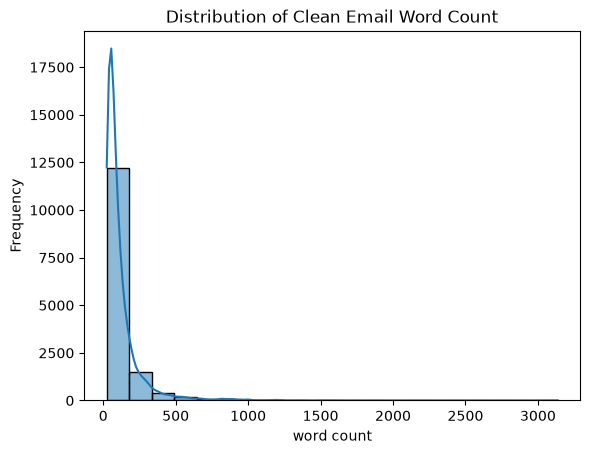

In [ ]:
# plot the distribution of clean email word count in the training dataset
sns.histplot(data=train_df, x='clean_email_word_count', bins=20, kde=True)
plt.title('Distribution of Clean Email Word Count')
plt.xlabel('word count')
plt.ylabel('Frequency')
plt.show()